# **Partie 0 - Installation, Téléchargements, Import**

## **Question 1 : Vérifier que le GPU est bien sélectionné**

In [ ]:
import torch

if torch.cuda.is_available():
    print("✅ GPU disponible :", torch.cuda.get_device_name(0))
else:
    print("❌ GPU non disponible")


✅ GPU disponible : Tesla T4


## **Instruction 1 : Installation de pytorch lightning**

In [ ]:
!pip install pytorch_lightning torchinfo

## **Question 2: Se connecter à la plateforme WanDB**

In [ ]:
import wandb

wandb.login()

wandb: Currently logged in as: icjxv (icjxv-universit-de-mons) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## **Question 3 : Télécharger le jeu de données d'entraînement : railway-construction-100** ##

In [ ]:
import zipfile
import os

zip_path = "/content/railway-construction-100.zip"
output_dir = "/content/data"

# Créer le dossier de destination s’il n’existe pas
os.makedirs(output_dir, exist_ok=True)

# Décompression
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print("✅ Données extraites dans :", output_dir)


✅ Données extraites dans : /content/data


## **Instruction 2 : Importation des libraries**

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler,Subset
import matplotlib.pyplot as plt
import cv2
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms.v2 as transforms
from tqdm import tqdm
from torchmetrics import Accuracy
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, TensorBoardLogger , CSVLogger
from torchmetrics.classification import MulticlassConfusionMatrix
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
import pandas as pd
import seaborn as sns

# **Partie 1 - Entraînement de modèle CNN**

## **Instruction 3 : Définir les paramètres d'entrainement**

In [ ]:
# Hyperparameters
dataset_path = "dataset/railway-construction-100/"  #@param ["dataset/railway-construction-50/","dataset/railway-construction-100/","dataset/railway-construction-big/"] {type:"string"}
batch_size = 32 #@param [8,16,32,64,128,256] {type:"raw"}
train_split = 0.8 #@param {type:"slider", min:0.5, max:0.9, step:0.05}
val_split = 0.1 #@param {type:"slider", min:0.1, max:0.5, step:0.05}
epochs = 10 #@param [1,5, 10,20,50,100,200] {type:"raw"}
learning_rate = 0.01  #@param [0.1, 0.01,0.02,0.05,0.001,0.002,0.005] {type:"raw"}
img_size = 224
num_classes = 4
LOG_DIR = "logs/"

## **Question 4 : Créer la classe «Model»  pour utiliser le CNN «efficientnet_v2_s»**

---



Compléter et adapter la classe «Model» vue au TP5 pour appliquer un transfert d’apprentissage à partir :
- du modèle «efficientnet_v2_s»,
- de la fonction d’erreur: CrossEntropyLoss,
- avec des poids définis en tant que « DEFAULT » dans le constructeur de la classe.
- avec l'ordre des classes sauvé sous self.classes

In [ ]:
class Model(pl.LightningModule):
    def __init__(self, num_classes=4, learning_rate=3e-4, weights="DEFAULT", classes=None):
        super().__init__()
        self.save_hyperparameters()

        self.classes = classes
        self.learning_rate = learning_rate

        # Chargement du backbone EfficientNet
        self.model = models.efficientnet_v2_s(weights=weights)

        # Geler les poids du backbone
        for param in self.model.parameters():
            param.requires_grad = False

        # Remplacer la tête de classification
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        # Fonction de perte
        self.criterion = nn.CrossEntropyLoss()

        # Métriques
        self.train_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.confusion_matrix = MulticlassConfusionMatrix(num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_accuracy.update(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_accuracy, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_accuracy.update(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_accuracy, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.test_accuracy.update(logits, y)
        self.confusion_matrix.update(logits, y)
        self.log("test_loss", loss)
        self.log("test_acc", self.test_accuracy)
        return loss

    def on_test_end(self):
        confmat = self.confusion_matrix.compute().cpu().numpy()
        self.test_accuracy.reset()
        plt.figure(figsize=(5, 4))
        sns.heatmap(confmat, annot=True, fmt="d", cmap="Blues",
                    xticklabels=self.classes, yticklabels=self.classes)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()
        self.confmat = confmat
        self.confusion_matrix.reset()


## **Question 5 : créer la fonction "create_data_loaders" : division et création des dataloaders**

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

def create_data_loaders(data_dir, batch_size=32, val_split=0.2, test_split=0.1):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    dataset = datasets.ImageFolder(data_dir, transform=transform)
    total_size = len(dataset)
    val_size = int(val_split * total_size)
    test_size = int(test_split * total_size)
    train_size = total_size - val_size - test_size

    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


## **Question 6 : créer les data loaders (train, val, test) avec la fonction create_data_loaders**

In [ ]:
data_dir = "/content/data/railway-construction-100"
train_loader, val_loader, test_loader = create_data_loaders(data_dir)

# Récupérer les noms de classes
class_names = train_loader.dataset.dataset.classes
print("Classes :", class_names)


Classes : ['excavator', 'train', 'train_tracks', 'workers']


## **Instruction 5: Définir "class_names" comme étant l'ordre des classes utilisées par le jeu de données, obtenable à partir de n'importe quel loader (train, val, test) précédemment défini**

In [ ]:
class_names = train_loader.dataset.dataset.classes

In [ ]:
print(train_loader.dataset.dataset.classes)

['excavator', 'train', 'train_tracks', 'workers']


## **Question 7 :  lancer l'entrainement en utilisant SGD avec lr='0.01'**

-	Modèle EfficientNet avec l’ordre des classes donnée en paramètre initial.
-	Pas d’apprentissage : '0.01’


In [ ]:
model = Model(num_classes=len(class_names), learning_rate=0.01, classes=class_names)

checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="best_model")
early_stopping_callback = EarlyStopping(monitor="val_acc", patience=5, mode="max")

wandb_logger = WandbLogger(project="TP7_XAI", log_model="all")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    callbacks=[checkpoint_callback, early_stopping_callback],
    logger=wandb_logger
)

trainer.fit(model, train_loader, val_loader)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                      | Params | Mode 
-----------------------------------------------------------------------
0 | model            | EfficientNet              | 20.2 M | train
1 | criterion        | CrossEntropyLoss          | 0      | train
2 | train_accuracy   | MulticlassAccuracy        | 0      | train
3 | val_accuracy     | MulticlassAccuracy        | 0      | train
4 | test_accuracy    | MulticlassAccuracy        | 0      | train
5 | confusion_matrix | MulticlassConfusionMatrix | 0      | train
-----------------------------------------------------------------------
5.1 K     Trainable params
20.2 M    Non-trainable params
20.2 M    Total params
80.730    Total estimated model params size (MB)
719       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (9) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


## **Question 7.1 : fonction de visulisation des courbes d'entrainement avec plot**

In [ ]:
def plot_metrics(trainer):
    metrics = trainer.logger.experiment.history()
    metrics_df = pd.DataFrame(metrics)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(metrics_df["train_loss"], label="Train Loss")
    plt.plot(metrics_df["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics_df["train_acc"], label="Train Acc")
    plt.plot(metrics_df["val_acc"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


## **Question 7.2 : Afficher vos courbes d'entrainement avec la fct "plot_metrics" et/ou WanDB**

https://wandb.ai/icjxv-universit-de-mons/TP7_XAI/runs/oof0os8w?nw=nwusericjxv

## **Question 8 : évaluer votre modèle avec les données de test**



INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

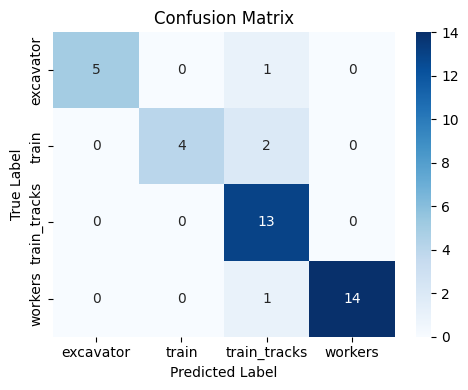

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8999999761581421     │
│         test_loss         │    0.6240381002426147     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.6240381002426147, 'test_acc': 0.8999999761581421}]

In [ ]:
trainer.test(model, test_loader)

## **Question 9 : calculer les métriques suivantes à partir des valeurs de la matrice de confusion :**

**Quelle est la classe qui présente le/la meilleure et inversément le/la pire:**

**Q8.1) Précision ?**

Meilleur : workers/train

Pire : excavator

**Q8.2) Recall?**

Meilleur : workers

Pire : train

**Q8.3) Score F-1 ?**

Meilleur : workers

Pire : train/excavator

## **Question 10 : proposer 3 façons (sans les appliquer) pour essayer d'améliorer la performance du modèle, liée ou non aux observations tirées sur les classes via la matrice de confusion**

1) Rajouter des train_data pour la classe train

2)

3) ???

# **Partie 2 - Explicabilité du modèle CNN**

Cette première partie liée à l'explicabilité vous propose d'utiliser les librairies *torchcam* et *captum* pour analyser les résultats obtenus sur des images de différentes classes sur votre modèle entraîné, ainsi qu'un autre modèle non entraîné, avec des méthodes disponibles de la librairie captum.

## **Instruction 6 : installer les librairies d'explicabilité torchcam et captum**

In [ ]:
!pip install torchcam captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


## **Instruction 7 : importer les fonctions/classes nécessaires pour l'explicabilité**

In [ ]:
from torchcam.methods import GradCAM, LayerCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import normalize, resize, to_pil_image
from captum.attr import GradientShap, Occlusion, IntegratedGradients, DeepLift, visualization as viz
import numpy as np
import torch.nn.functional as F

## **Question 10 : créer le modèle "rand_model" EfficientNet NON entraîné SANS poids prédéfinis**

Ce modèle utilisera des poids aléatoire, afin de comparer ensuite l'explicabilité entre votre modèle précédemment entraîné ("model") et le modèle non entraîné ("rand_model")**

In [ ]:
rand_model = models.efficientnet_v2_s(weights=None)
rand_model.classifier[1] = nn.Linear(rand_model.classifier[1].in_features, len(class_names))

## **Instruction 8: analyser et exécuter la fonction d'extraction d'images de test par classe**

In [ ]:
# Function to extract and organize test images by class
def get_test_images_by_class(test_loader, num_images_per_class=5):
    """
    Extract and organize test images by class, including their paths.

    Args:
        test_loader: DataLoader containing test images
        num_images_per_class: Number of images to extract per class (default: 5)

    Returns:
        Dictionary with class names as keys and lists of (image, label, path) tuples as values
    """
    num_images_per_class = int(num_images_per_class)
    images_by_class = {class_name: [] for class_name in test_loader.dataset.dataset.classes}

    # Get the dataset and sampler from the test loader
    dataset = test_loader.dataset.dataset  # This is the ImageFolder dataset
    subset_indices = test_loader.dataset.indices  # These are the indices for our test subset

    # Iterate through the subset indices
    for idx in subset_indices:
        # Get the image path and label from the original dataset
        path, label = dataset.samples[idx]
        img = dataset[idx][0]  # Get the transformed image
        class_name = dataset.classes[label]

        if len(images_by_class[class_name]) < num_images_per_class:
            images_by_class[class_name].append((img, label, path))

        # Check if we have enough images for each class
        if all(len(imgs) >= num_images_per_class for imgs in images_by_class.values()):
            print("\nExtracted test images by class:")
            for class_name, images in images_by_class.items():
                print(f"{class_name}: {len(images)} images")
            return images_by_class

    print("\nExtracted test images by class:")
    for class_name, images in images_by_class.items():
        print(f"{class_name}: {len(images)} images")
    return images_by_class

## **Instruction 9 : analyser et exécuter la fonction d'explication contenant un ensemble de méthodes d'explicabilité pour CNN**

In [ ]:
def explain_model(model, img_input, label, classofexplainability, path, device="cuda"):
    # Move model and inputs to the specified device
    model.to(device)
    img_input = img_input.to(device)

    idx_to_class = {v: k for k, v in test_loader.dataset.dataset.class_to_idx.items()}
    output = model(img_input)
    output = F.softmax(output, dim=1)
    prediction_score, pred_label_idx = torch.topk(output, 1)
    print("pred_label_idx:", pred_label_idx)
    if classofexplainability.lower() == "gradientshap":
        gradient_shap = GradientShap(model)
        rand_img_dist = torch.rand(50, 3, 224, 224).to(device)  # Random baseline distribution
        attributions_zero = gradient_shap.attribute(img_input,
                                               n_samples=50,
                                               stdevs=0.0001,
                                               baselines=rand_img_dist,
                                               target=pred_label_idx)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "occlusion":
        occlusion = Occlusion(model)
        # Change is here:
        attributions_zero = occlusion.attribute(img_input,
                                            target=pred_label_idx.squeeze(1), # Squeeze to 1D
                                            strides=(3, 8, 8),
                                            sliding_window_shapes=(3, 15, 15),
                                            baselines=0)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "integratedgradients":
        ig = IntegratedGradients(model)
        baseline = torch.zeros_like(img_input).to(device)  # Zero baseline
        attributions_zero = ig.attribute(img_input, baselines=baseline, target=pred_label_idx)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels

    elif classofexplainability.lower() == "deeplift":
        deeplift = DeepLift(model)
        baseline = torch.zeros_like(img_input).to(device)  # Zero baseline
        attributions_zero = deeplift.attribute(img_input, target=pred_label_idx, baselines=baseline)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "gradcam":
        cam_extractor = GradCAM(model, target_layer=model.model.features[-1])
        out = model(img_input.to(device))
        # Retrieve the CAM by passing the class index and the model output
        activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
        attributions = activation_map[0]

        # Once you're finished, clear the hooks on your model
        cam_extractor.remove_hooks()
        # return
    elif classofexplainability.lower() == "layercam":
        cam_extractor = LayerCAM(model, target_layer=model.model.features[-1])
        out = model(img_input.to(device))
        # Retrieve the CAM by passing the class index and the model output
        activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
        attributions = activation_map[0]

        # Once you're finished, clear the hooks on your model
        cam_extractor.remove_hooks()
        # return
    else:
        raise ValueError(f"Unsupported explainability method: {classofexplainability}")

    fig, ax = plt.subplots(1, 4, figsize=(16,12))
    input_img = img_input.squeeze(0).cpu().detach().numpy().transpose(1,2,0) # Convert to numpy array
    attributions = attributions.squeeze(0).cpu().detach().numpy() # Convert to numpy array
    attributions = (attributions - attributions.min())/(attributions.max()-attributions.min()) # Normalize to [0,1]
    ax[0].imshow(input_img, cmap="turbo")
    ax[1].imshow(attributions, cmap="jet")
    ax[2].imshow(overlay_mask(to_pil_image(input_img), to_pil_image(attributions, mode='F'), alpha=0.5))
    ax[0].set_title("Original Image")
    ax[1].set_title(classofexplainability)
    ax[2].set_title("Overlay")
    actual_class = test_loader.dataset.dataset.classes[label]
    predicted_class = test_loader.dataset.dataset.classes[pred_label_idx.item()]
    isCorrect = predicted_class==actual_class
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Create a copy of input_img for CV2 operations
    font = cv2.FONT_HERSHEY_COMPLEX
    font_scale, thickness = img.shape[1]/350, max(2, int(img.shape[1]/350*2))
    textsize = cv2.getTextSize(predicted_class, font, font_scale, thickness)[0]
    textX = (img.shape[1] - textsize[0]) // 2
    textY = (img.shape[0] + textsize[1]) // 2 - 50

    # Add text to the image
    cv2.putText(img, predicted_class, (int(textX), int(textY)), font, font_scale,
                (0,255,0) if isCorrect else (255,0,0), thickness, cv2.LINE_AA)

    # Display the image with text
    ax[3].imshow(img)

    # Add title
    title_text = "Bonne prédiction : {:.2f}".format(prediction_score.item()) if isCorrect else \
                 "FAUX: {} {:.2f}; REAL: {}".format(predicted_class, prediction_score.item(), actual_class)
    title = ax[3].set_title(title_text, fontsize=20)
    plt.setp(title, color='g' if isCorrect else 'r')

## **Instruction 10: choisir un nombre d'images par classe à extraire, une classe, une méthode XAI et le modèle entraîné pour obtenir des résultats sur les images spécifiées ci-dessous.**

In [ ]:
num_images_per_class = "5" #@param[3, 5, 7, 10, 15]
class_name = "train_tracks" #@param["train", "train_tracks", "workers", "excavator"]

method = "integratedgradients" #@param["gradientshap", "occlusion", "integratedgradients", "gradcam", "deeplift", 'layercam']
model_choice = "model" #@param["model", "rand_model"]

dictioModels = {"model": model, "rand_model":rand_model}

## **Question 11 : Extraire les images par classe qui seront analysées sous "test_images".**

In [ ]:
# Get test images by class
from collections import defaultdict

def extract_images_by_class(dataloader, num_images_per_class=5):
    class_images = defaultdict(list)
    for x, y in dataloader:
        for img, label in zip(x, y):
            if len(class_images[label.item()]) < num_images_per_class:
                class_images[label.item()].append(img)
        if all(len(imgs) >= num_images_per_class for imgs in class_images.values()):
            break
    return class_images

images_by_class = extract_images_by_class(test_loader, num_images_per_class=3)


## **Question 12 : Compléter le code pour expliquer les résultats du modèle sur les images extraites.**

In [ ]:
# Select model and set it to device and eval mode
usedModel = model  # ou rand_model pour tester l'autre cas
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
usedModel.to(device).eval()

torch.set_grad_enabled(True)
# Make sure model parameters have requires_grad=True
for param in usedModel.parameters():
    param.requires_grad = True

# Explain images for class
print("Explaining images for class:", class_name)
for img, label in images_by_class[class_name]:
    img = img.clone().detach().requires_grad_().unsqueeze(0).to(device)
    print("method:", method)

    # Exemple avec Captum - Gradient Saliency
    from captum.attr import Saliency
    import matplotlib.pyplot as plt

    saliency = Saliency(usedModel)
    attributions = saliency.attribute(img, target=label.item())
    attributions = attributions.squeeze().cpu().detach().numpy()

    # Affichage
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.title("Image originale")
    plt.imshow(img.squeeze().permute(1, 2, 0).cpu())
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Carte de salience")
    plt.imshow(np.abs(attributions).sum(axis=0), cmap='hot')
    plt.axis("off")
    plt.show()

    # Clean up any remaining hooks
    for handle in usedModel.model.features.named_modules():
        if hasattr(handle[1], '_backward_hooks'):
            handle[1]._backward_hooks.clear()
        if hasattr(handle[1], '_forward_hooks'):
            handle[1]._forward_hooks.clear()
        if hasattr(handle[1], '_forward_pre_hooks'):
            handle[1]._forward_pre_hooks.clear()


Explaining images for class: train_tracks


## **Question 13 : Faites tourner le code avec les différentes méthodes sur le modèle entraîné. Quelle méthode vous semble donner de meilleurs résultats ?**

La méthode IntegratedGradients donne les meilleurs résultats car elle donne des meilleures explications et beaucoup plus claires

## **Question 14 : Analyser maintenant les résultats en faisant tourner le code pour chacune des classes sur cette méthode XAI. Observez-les bonnes et mauvaises prédictions et proposez une manière d'améliorer le modèle.**

Ajouter des transformations d’augmentation de données réalistes pour entrainer le modèle à mieux détecter les cas defectueux.

## **Question 15 : Utiliser maintenant le modèle non entraîné. Quelles différences constatez-vous entre le modèle entraîné et le modèle sans poids prédéfinis ?**

Le modèl non entrainer n'a pas de compréhension sémantique de l'image. Cela donne donc des résultats inutilisables.

# **Partie 3 - Entraînement VIT et Explicabilité**

## **Question 16 : créer classe «Model_Vit»  pour utiliser le modèle «vit_b_16» : TP6**

In [ ]:
class Model_ViT(pl.LightningModule):
    def __init__(self, learning_rate=3e-4, weights="DEFAULT", classes=None):
        super().__init__()
        self.save_hyperparameters()

        self.classes = classes
        self.learning_rate = learning_rate

        self.model = models.vit_b_16(weights=weights)

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Linear(in_features, len(classes))

        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(task="multiclass", num_classes=len(classes))
        self.val_accuracy = Accuracy(task="multiclass", num_classes=len(classes))
        self.test_accuracy = Accuracy(task="multiclass", num_classes=len(classes))
        self.confusion_matrix = MulticlassConfusionMatrix(num_classes=len(classes))

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_accuracy.update(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_accuracy, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_accuracy.update(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_accuracy, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.test_accuracy.update(logits, y)
        self.confusion_matrix.update(logits, y)
        self.log("test_loss", loss)
        self.log("test_acc", self.test_accuracy)
        return loss

    def on_test_end(self):
        confmat = self.confusion_matrix.compute().cpu().numpy()
        self.test_accuracy.reset()
        plt.figure(figsize=(5, 4))
        sns.heatmap(confmat, annot=True, fmt="d", cmap="Blues",
                    xticklabels=self.classes, yticklabels=self.classes)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()
        self.confusion_matrix.reset()


## **Question 17 :  lancer l'entrainement avec le modèle vit_b_16 en utilisant SGD avec lr='0.01'**

-	Modèle Vit_b_16 avec l’ordre des classes donné en paramètre initial.
-	Pas d’apprentissage : '0.01’


In [ ]:
model_vit = Model_ViT(learning_rate=0.01, weights="DEFAULT", classes=class_names)

checkpoint_callback_vit = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="best_model_vit"
)

early_stopping_callback_vit = EarlyStopping(
    monitor="val_acc",
    patience=5,
    mode="max"
)

wandb_logger_vit = WandbLogger(project="TP7_XAI_ViT", log_model="all")

trainer_vit = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    callbacks=[checkpoint_callback_vit, early_stopping_callback_vit],
    logger=wandb_logger_vit
)

trainer_vit.fit(model_vit, train_loader, val_loader)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 146MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type                      | Params | Mode 
-----------------------------------------------------------------------
0 | model            | VisionTrans

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (9) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## **Question 18 : évaluer votre modèle vit avec les données de test**



INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

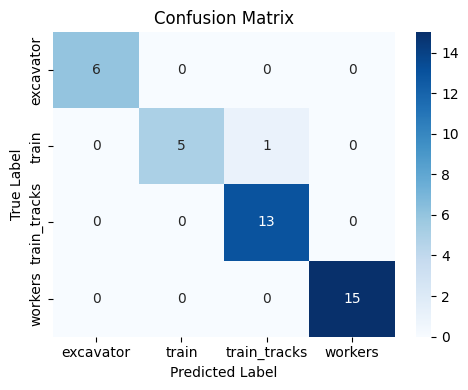

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9750000238418579     │
│         test_loss         │    0.31108683347702026    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.31108683347702026, 'test_acc': 0.9750000238418579}]

In [ ]:
trainer_vit.test(model_vit, test_loader)

## **Instruction 11 : télécharger le Github « Transformer Input Sampling » et installer les imports nécessaires à son bon fonctionnement**

*Transformer Input Sampling (TIS)* : Méthode d'explicabilité spécifique aux Vision Transformers utilisant des masques basés sur les sorties des couches d'attention; Cette méthode a été développée et publiée par des chercheurs belges dont un de l'UMONS faisant partie de l'équipe ILIA.

In [ ]:
!git clone https://github.com/aenglebert/Transformer_Input_Sampling.git

Cloning into 'Transformer_Input_Sampling'...
remote: Enumerating objects: 497, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 497 (delta 65), reused 70 (delta 28), pack-reused 374 (from 1)
Receiving objects: 100% (497/497), 108.16 KiB | 5.41 MiB/s, done.
Resolving deltas: 100% (272/272), done.


In [ ]:
!pip install timm@git+https://github.com/rwightman/pytorch-image-models@18ec173f95aa220af753358bf860b16b6691edb2
!pip install fast-pytorch-kmeans
!pip install scikit-image einops opencv-python ttach

  Cloning https://github.com/rwightman/pytorch-image-models (to revision 18ec173f95aa220af753358bf860b16b6691edb2) to /tmp/pip-install-i96d1skw/timm_b6ec2811588842eeb00c13abc57315ae
  Running command git clone --filter=blob:none --quiet https://github.com/rwightman/pytorch-image-models /tmp/pip-install-i96d1skw/timm_b6ec2811588842eeb00c13abc57315ae
  Running command git rev-parse -q --verify 'sha^18ec173f95aa220af753358bf860b16b6691edb2'
  Running command git fetch -q https://github.com/rwightman/pytorch-image-models 18ec173f95aa220af753358bf860b16b6691edb2
  Running command git checkout -q 18ec173f95aa220af753358bf860b16b6691edb2
  Resolved https://github.com/rwightman/pytorch-image-models to commit 18ec173f95aa220af753358bf860b16b6691edb2
  Preparing metadata (setup.py) ... done
  Created wheel for timm: filename=timm-0.8.1.dev0-py3-none-any.whl size=567594 sha256=4566fa7b301e2724a3da6939aec2f7a72bffbf1ae05ea1fe9b4cc16c2445a53b
  Stored in directory: /root/.cache/pip/wheels/de/1f/cd/

## **Instruction 12 : analyser et exécuter la fonction d'explication contenant un ensemble de méthodes d'explicabilité pour ViT**

*Il est possible que la première exécution de l'import de TIS dans Google Colab produise une erreur, qui ne sera plus présente à la seconde exécution*

In [ ]:
from Transformer_Input_Sampling.tis import TIS

In [ ]:
def explain_model_vit(model, img_input, label, classofexplainability, path, device="cuda"):
    # Move model and inputs to the specified device
    model.to(device)
    img_input = img_input.to(device)

    idx_to_class = {v: k for k, v in test_loader.dataset.dataset.class_to_idx.items()}
    output = model(img_input)
    output = F.softmax(output, dim=1)
    prediction_score, pred_label_idx = torch.topk(output, 1)
    print("pred_label_idx:", pred_label_idx)
    if classofexplainability.lower() == "gradientshap":
        gradient_shap = GradientShap(model)
        rand_img_dist = torch.rand(50, 3, 224, 224).to(device)  # Random baseline distribution
        attributions_zero = gradient_shap.attribute(img_input,
                                               n_samples=50,
                                               stdevs=0.0001,
                                               baselines=rand_img_dist,
                                               target=pred_label_idx)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "occlusion":
        occlusion = Occlusion(model)
        # Change is here:
        attributions_zero = occlusion.attribute(img_input,
                                            target=pred_label_idx.squeeze(1), # Squeeze to 1D
                                            strides=(3, 8, 8),
                                            sliding_window_shapes=(3, 15, 15),
                                            baselines=0)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "integratedgradients":
        ig = IntegratedGradients(model)
        baseline = torch.zeros_like(img_input).to(device)  # Zero baseline
        attributions_zero = ig.attribute(img_input, baselines=baseline, target=pred_label_idx)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels

    elif classofexplainability.lower() == "deeplift":
        deeplift = DeepLift(model)
        baseline = torch.zeros_like(img_input).to(device)  # Zero baseline
        attributions_zero = deeplift.attribute(img_input, target=pred_label_idx, baselines=baseline)
        attributions = attributions_zero.sum(dim=1) # Sum over the channels
    elif classofexplainability.lower() == "gradcam":
        cam_extractor = GradCAM(model, target_layer=model.model.features[-1])
        out = model(img_input.to(device))
        # Retrieve the CAM by passing the class index and the model output
        activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
        attributions = activation_map[0]

        # Once you're finished, clear the hooks on your model
        cam_extractor.remove_hooks()
        # return
    elif classofexplainability.lower() == "tis":
        tis_m = TIS(model.model, n_masks=1024, batch_size=128)
        attributions = tis_m(img_input.to(device)).cpu()
    else:
        raise ValueError(f"Unsupported explainability method: {classofexplainability}")

    fig, ax = plt.subplots(1, 4, figsize=(16,12))
    input_img = img_input.squeeze(0).cpu().detach().numpy().transpose(1,2,0) # Convert to numpy array
    attributions = attributions.squeeze(0).cpu().detach().numpy() # Convert to numpy array
    attributions = (attributions - attributions.min())/(attributions.max()-attributions.min()) # Normalize to [0,1]
    ax[0].imshow(input_img, cmap="turbo")
    ax[1].imshow(attributions, cmap="jet")
    ax[2].imshow(overlay_mask(to_pil_image(input_img), to_pil_image(attributions, mode='F'), alpha=0.5))
    ax[0].set_title("Original Image")
    ax[1].set_title(classofexplainability)
    ax[2].set_title("Overlay")
    actual_class = test_loader.dataset.dataset.classes[label]
    predicted_class = test_loader.dataset.dataset.classes[pred_label_idx.item()]
    isCorrect = predicted_class==actual_class
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Create a copy of input_img for CV2 operations
    font = cv2.FONT_HERSHEY_COMPLEX
    font_scale, thickness = img.shape[1]/350, max(2, int(img.shape[1]/350*2))
    textsize = cv2.getTextSize(predicted_class, font, font_scale, thickness)[0]
    textX = (img.shape[1] - textsize[0]) // 2
    textY = (img.shape[0] + textsize[1]) // 2 - 50

    # Add text to the image
    cv2.putText(img, predicted_class, (int(textX), int(textY)), font, font_scale,
                (0,255,0) if isCorrect else (255,0,0), thickness, cv2.LINE_AA)

    # Display the image with text
    ax[3].imshow(img)

    # Add title
    title_text = "Bonne prédiction : {:.2f}".format(prediction_score.item()) if isCorrect else \
                 "FAUX: {} {:.2f}; REAL: {}".format(predicted_class, prediction_score.item(), actual_class)
    title = ax[3].set_title(title_text, fontsize=20)
    plt.setp(title, color='g' if isCorrect else 'r')

## **Question 19 : complèter le code en sélectionnant une méthode d'explicabilité initiale et le modèle ViT, et appliquer la fonction "explain_model_vit"**

In [ ]:
method = "gradientshap"  # @param["gradientshap", "occlusion", "integratedgradients", "deeplift", "tis"]
class_name = "train"     # @param["train", "train_tracks", "workers", "excavator"]

model_vit.to(device).eval()

torch.set_grad_enabled(True)
for param in model_vit.parameters():
    param.requires_grad = True

for img, label in images_by_class[class_name]:
    img = img.clone().detach().requires_grad_().unsqueeze(0).to(device)

    if method == "gradientshap":
        from captum.attr import GradientShap
        explainer = GradientShap(model_vit)
        baseline = torch.zeros_like(img).to(device)
        attributions = explainer.attribute(img, baselines=baseline, target=label.item())

    elif method == "occlusion":
        from captum.attr import Occlusion
        explainer = Occlusion(model_vit)
        attributions = explainer.attribute(img, strides=(3, 8, 8), sliding_window_shapes=(3, 15, 15), target=label.item())

    elif method == "integratedgradients":
        from captum.attr import IntegratedGradients
        explainer = IntegratedGradients(model_vit)
        attributions = explainer.attribute(img, target=label.item())

    elif method == "deeplift":
        from captum.attr import DeepLift
        explainer = DeepLift(model_vit)
        attributions = explainer.attribute(img, target=label.item())

    elif method == "tis":
        print("La méthode TIS nécessite des modules spécifiques à télécharger (Transformer Input Sampling).")

    # Affichage de la heatmap
    attributions = attributions.squeeze().cpu().detach().numpy()
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.title("Image originale")
    plt.imshow(img.squeeze().permute(1, 2, 0).cpu())
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Attribution heatmap")
    plt.imshow(np.abs(attributions).sum(axis=0), cmap='hot')
    plt.axis("off")
    plt.show()


## **Question 20 : tourner le code avec les différentes méthodes sur le modèle ViT. Quelle méthode vous semble donner de meilleurs résultats ?**

La méthode integratedGradiants est la plus efficace pour vit car elle est plus rapide , claire, stable et met en évidence les régions influentes de l'image

## **Question 21 :** analyser les résultats en faisant tourner le code pour chacune des classes sur cette méthode XAI. Observez-les bonnes et mauvaises prédictions et proposez une manière d'améliorer le modèle.

Les explications sont globalement cohérentes, cependant, la classe excavator présente quelques cofusion. En effet, les régions activées sont parfois floues/mal localisée. Pour améliorer les performances, on pourrait enrichir les données d'entrainementsavec des cas bien variées.

# **Partie 4 (Optionnel) - Méthodes XAI de perturbation - "RISE"**

Le principe fondamental des méthodes de perturbation visant à générer une explication du résultat d'un modèle Deep Learning est de perturber l’image d’entrée originale (= supprimer des pixels, des zones de pixels de l'image initiale) et de calculer le score obtenu sur cette image perturbée.

En répétant cette opération des centaines/ milliers de fois selon la taille de l’image, on peut trouver quelles parties de l’image sont les plus importantes pour la décision d’un réseau. Une méthode fonctionnant bien dans l’état de l’art du milieu XAI est la méthode « RISE » dont voici le schéma de fonctionnement ci-dessous :

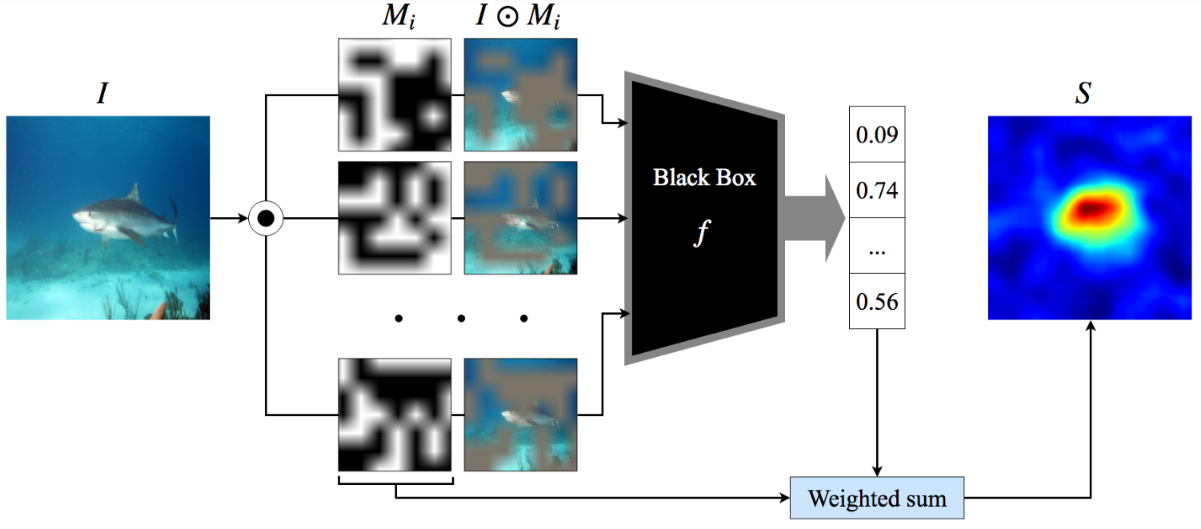

[1] Petsiuk, V., Das, A., & Saenko, K. (2018). Rise: Randomized input sampling for explanation of black-box models. arXiv preprint arXiv:1806.07421.

Il vous est demandé de compléter le code suivant (inspiré de [1]) pour aboutir au schéma de la Figure 1, dont voici les étapes principales :

1. Créer des masques aléatoires ($M_i$) de pixels à appliquer sur une image ($I$)
2. Application de ceux-ci sur l'image ($I \odot M_i$)
3. Prédiction des images avec masques par le modèle AI ($f$)
4. Combinaison linéaire des masques par un poids équivalent à la prédiction du point 3. pour produire la heatmap d'explicabilité

---

In [ ]:
# Compléter la Fonction équivalente au point 1 - Création de masques aléatoires de pixels
from PIL import Image

def create_mask(h=7, w=7, H=224, W=224, p_1=0.5, resample=Image.BILINEAR):
    """Creation of random masks for the RISE method."""
    # Random mask of size (h,w) and values [0, 1] with probabilites (1-p-1, p1)
    mask = np.random.choice(['???', '???'], size=('???', '???'), p=[1 - '???', '???'])

    # Resizing
    mask = Image.fromarray('???' * 255.)
    mask = mask.resize((H + h, W + w), resample=resample)
    mask = np.array(mask) # previously np.array

    # Crop to HxW
    w_crop = np.random.randint(0, w + 1)
    h_crop = np.random.randint(0, h + 1)
    mask = mask[h_crop:'???'+ h_crop, w_crop:'???' + w_crop]

    # Normalization
    mask /= torch.max(torch.from_numpy(mask))

    return mask

In [ ]:
# Compléter la fonction équivalente au point 4 - Combinaison linéaire des masques avec leur poids

def create_sum_mask(masks, preds_masked, class_index):
    sum_mask = torch.zeros(masks[0].shape, dtype=torch.float32)

    for i, mask in enumerate(masks):
        # Combinaison linéaire de chaque masques et de leur poids pour une classe spécifique du modèle à expliquer
        m = '???' * '???'[i, '???']
        # Somme des pondérations
        sum_mask += m

    # Normalisation
    sum_mask -= torch.min(sum_mask)
    sum_mask /= torch.max(sum_mask)

    return sum_mask

<>:8: SyntaxWarning: str indices must be integers or slices, not tuple; perhaps you missed a comma?
<>:8: SyntaxWarning: str indices must be integers or slices, not tuple; perhaps you missed a comma?
<ipython-input-40-4848b9279722>:8: SyntaxWarning: str indices must be integers or slices, not tuple; perhaps you missed a comma?
  m = '???' * '???'[i, '???']


In [ ]:
# Fonction utilitaire pour montrer les résultats de RISE
def rgb2gray(rgb):
    '''Convert RGB to GrayScale, according to OpenCV convertion.'''
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2990 * r + 0.5870 * g + 0.1140 * b
    return gray

In [ ]:
# Size of small masks (h,w) which will be sized to image_size
h = 7
w = 7

# Pixel probability of being 1 (if not it is 0)
P_1 = 0.5

# Number of masks
N_MASKS = 4000

# Image size
IMAGE_SIZE = (3, 224, 224)

# Define batch size
BATCH_SIZE = 32  # Adjust this based on your available RAM

model_for_rise = model # model or model_vit
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Image de départ
img = test_images["excavator"][0][0]
img_exp = img.unsqueeze(0)
img_gray = rgb2gray(img)
print(img.shape)

X = torch.zeros((N_MASKS, ) + IMAGE_SIZE, dtype=torch.float32)
masks = torch.zeros((N_MASKS, ) + IMAGE_SIZE[1:], dtype=torch.float32)
print(X.shape)
print(masks.shape)

# Point 1 & 2 - Créer les masques et les appliquer sur l'image
for i in tqdm(range(N_MASKS)):
    # Point 1 - Créer un masque
    m = create_mask(h=h, w=w, H=IMAGE_SIZE[1], W=IMAGE_SIZE[2], p_1=P_1, resample=Image.BILINEAR)
    masks[i] = torch.tensor(m, dtype=torch.float32)

    # Point 2 - Appliquer le masque sur l'image
    x = img.clone()
    x[0, :, :] *= torch.tensor(m, dtype=torch.float32)
    x[1, :, :] *= torch.tensor(m, dtype=torch.float32)
    x[2, :, :] *= torch.tensor(m, dtype=torch.float32)
    X[i] = x


IndexError: list index out of range

In [ ]:
# Point 3 - Prédire les résultats sur les images masquées

# Initialize array to store all predictions
preds_masked = torch.zeros((N_MASKS, len(class_names)))
model_for_rise.to(device).eval()

# Process in batches
for i in range(0, N_MASKS, BATCH_SIZE):
    batch_end = min(i + BATCH_SIZE, N_MASKS)
    batch_X = X[i:batch_end].to(device)

    with torch.no_grad():  # Disable gradient computation for inference
        batch_preds = model_for_rise(batch_X)

    preds_masked[i:batch_end] = batch_preds.cpu()  # Store predictions

    # Optional: Clear GPU cache if needed
    if device.type == 'cuda':
        torch.cuda.empty_cache()

In [ ]:
# Montrer les résultats de RISE sur la premières et la dernière classe prédite par le modèle

pred_unmasked = model_for_rise(img_exp.to(device))
pred_unmasked = torch.softmax(pred_unmasked, 1).cpu().detach().numpy()[0]
print(pred_unmasked)
result = [(class_names[i], float(pred_unmasked[i]) * 100.0) for i in range(len(pred_unmasked))]
result.sort(reverse=True, key=lambda x: x[1])
print(result)

(class_name1, prob1) = result[0]
(class_name2, prob2) = result[1]
(class_name3, prob3) = result[2]
(class_name4, prob4) = result[3]
class_index1 = class_names.index(class_name1)
class_index2 = class_names.index(class_name2)
class_index3 = class_names.index(class_name3)
class_index4 = class_names.index(class_name4)

# Point 4 -
sum_mask = 'Fonction ???'(masks, preds_masked, '???')
sum_mask2 = 'Fonction ???'(masks, preds_masked, '???')
sum_mask3 = 'Fonction ???'(masks, preds_masked, '???')
sum_mask4 = 'Fonction ???'(masks, preds_masked, '???')

# Display heatmaps
plt.figure(figsize=(15, 5))
plt.subplot(151)
plt.title('Original Image')
plt.axis('off')
plt.imshow(img.permute((1,2,0)))

plt.subplot(152)
plt.title('RISE for {!r}:'.format(class_name1))
plt.axis('off')
plt.imshow(img_gray, cmap=plt.cm.gray)
plt.imshow(sum_mask, cmap=plt.cm.jet, alpha=0.7)

plt.subplot(153)
plt.title('RISE for {!r}:'.format(class_name2))
plt.axis('off')
plt.imshow(img_gray, cmap=plt.cm.gray)
plt.imshow(sum_mask2, cmap=plt.cm.jet, alpha=0.7)

plt.subplot(154)
plt.title('RISE for {!r}:'.format(class_name3))
plt.axis('off')
plt.imshow(img_gray, cmap=plt.cm.gray)
plt.imshow(sum_mask3, cmap=plt.cm.jet, alpha=0.7)

plt.subplot(155)
plt.title('RISE for {!r}:'.format(class_name4))
plt.axis('off')
plt.imshow(img_gray, cmap=plt.cm.gray)
plt.imshow(sum_mask4, cmap=plt.cm.jet, alpha=0.7)

plt.show()